# RS Lab4: Sistemas de recomendación con grafos y transformers

**Curso:** Sistemas de Recomendación

## Objetivos de aprendizaje

Al finalizar este laboratorio podrás:

1. Representar interacciones usuario-item como un **grafo bipartito**.
2. Construir una matriz de adyacencia/transición desde un grafo pequeño y avanzar iteraciones de PageRank.
3. Aplicar **Personalized PageRank** para recomendar items no vistos.
3. Comparar recomendaciones de PageRank con un baseline de popularidad.
4. Convertir ratings con timestamp en **secuencias de interacción**.
5. Entrenar un transformer tipo **SASRec** de complejidad moderada para predicción del siguiente item en CPU.
6. Entender qué aporta una librería como **Transformers4Rec** y por qué no la ejecutaremos directamente en este entorno CPU-only.

Usaremos **MovieLens Latest-Small** durante todo el laboratorio para concentrarnos en los conceptos y no en la preparación de múltiples datasets. En la versión 3, la parte de transformers usa un subconjunto más amplio y un modelo más profundo para que el entrenamiento tome minutos y permita observar mejor la optimización.

## Mapa conceptual del laboratorio

En la primera parte ignoraremos el orden temporal y usaremos la estructura de red entre usuarios y películas. En la segunda parte usaremos el orden de las interacciones para construir secuencias.

```text
ratings.csv
   ├── Parte 1: grafo usuario-película ──> Personalized PageRank ──> ranking de películas
   └── Parte 2: secuencias por usuario ──> transformer causal ──> siguiente película probable
```

**Idea clave:** PageRank explota conectividad global; el transformer explota orden temporal y contexto reciente.

In [1]:
# ============================================================
# Instalación de librerías necesarias desde el notebook
# ============================================================
# Ejecuta esta celda al inicio. Si una librería ya está instalada,
# no se reinstala. Esto permite usar el notebook sin preparar
# previamente un archivo requirements.txt.

import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "networkx": "networkx",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "torch": "torch",
    "tqdm": "tqdm",
}

missing = [pip_name for import_name, pip_name in REQUIRED_PACKAGES.items()
           if importlib.util.find_spec(import_name) is None]

if missing:
    print("Instalando librerías faltantes:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("Todas las librerías necesarias ya están instaladas.")


Todas las librerías necesarias ya están instaladas.


In [2]:
# ============================================================
# 0. Configuración general
# ============================================================
from pathlib import Path
import math
import time
import zipfile
import urllib.request
import warnings

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = Path("ml-latest-small")
ZIP_PATH = Path("ml-latest-small.zip")
ZIP_URL = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"

print("Entorno listo")

Entorno listo


In [3]:
# ============================================================
# 1. Descarga y carga de MovieLens Latest-Small
# ============================================================
if not DATA_DIR.exists():
    print("Descargando MovieLens Latest-Small...")
    urllib.request.urlretrieve(ZIP_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(".")
    ZIP_PATH.unlink(missing_ok=True)
else:
    print(f"Dataset ya disponible en {DATA_DIR}/")
    ZIP_PATH.unlink(missing_ok=True)

ratings = pd.read_csv(
    DATA_DIR / "ratings.csv",
    dtype={"userId": "int32", "movieId": "int32", "rating": "float32", "timestamp": "int64"},
)
movies = pd.read_csv(DATA_DIR / "movies.csv", dtype={"movieId": "int32"})
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s", utc=True)

print(f"ratings: {ratings.shape}")
print(f"movies : {movies.shape}")
display(ratings.head())
display(movies.head())

Dataset ya disponible en ml-latest-small/
ratings: (100836, 5)
movies : (9742, 3)


,userId,movieId,rating,timestamp,datetime
0,1,1,4.0,964982703,2000-07-30 18:45:03+00:00
1,1,3,4.0,964981247,2000-07-30 18:20:47+00:00
2,1,6,4.0,964982224,2000-07-30 18:37:04+00:00
3,1,47,5.0,964983815,2000-07-30 19:03:35+00:00
4,1,50,5.0,964982931,2000-07-30 18:48:51+00:00


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


### Pregunta de interpretación 0

MovieLens contiene `userId`, `movieId`, `rating` y `timestamp`.

1. ¿Cuál de estas columnas se convierte naturalmente en nodos de un grafo?
2. ¿Cuál se convierte en peso de una arista?
3. ¿Por qué `timestamp` será más importante en la parte de transformers que en la parte de PageRank?

**Respuesta del estudiante:** escribe tu respuesta en la celda vacía de abajo.

1. ¿Cuál de estas columnas se convierte naturalmente en nodos de un grafo?

userId y movieId. Cada usuario único y cada película única se convierten en nodos de un grafo bipartito: un conjunto de nodos representa usuarios y el otro representa películas. Una arista conecta un usuario con una película cuando existe una interacción (rating) entre ellos.

2. ¿Cuál se convierte en peso de una arista?

rating. El valor numérico del rating (de 0.5 a 5.0) representa la intensidad o confianza de la interacción entre un usuario y una película, por lo que se usa como peso de la arista que los conecta. Un rating más alto indica una preferencia más fuerte.

3. ¿Por qué timestamp será más importante en la parte de transformers que en la parte de PageRank?

PageRank modela la estructura estática del grafo: lo que importa es quién está conectado con quién y con qué peso, sin importar cuándo ocurrió la interacción. El orden temporal no afecta el cálculo de puntajes.

En cambio, el transformer secuencial (SASRec) necesita el timestamp para ordenar las interacciones de cada usuario cronológicamente y construir una secuencia [i1, i2, i3, ...]. El modelo aprende patrones de orden: qué películas suele ver un usuario después de otras. Sin el orden temporal correcto, la secuencia sería arbitraria y el modelo no podría aprender transiciones significativas entre items.

In [4]:
# Estadísticas rápidas del dataset
summary = pd.DataFrame(
    {
        "métrica": ["usuarios", "películas", "ratings", "rating mínimo", "rating máximo"],
        "valor": [
            ratings["userId"].nunique(),
            ratings["movieId"].nunique(),
            len(ratings),
            ratings["rating"].min(),
            ratings["rating"].max(),
        ],
    }
)
display(summary)

,métrica,valor
0,usuarios,610.0
1,películas,9724.0
2,ratings,100836.0
3,rating mínimo,0.5
4,rating máximo,5.0


# Parte 1A — PageRank paso a paso: de un grafo a una recomendación

Antes de aplicar PageRank a MovieLens, vamos a resolver un ejemplo pequeño **a mano y con código**. Esta sección está pensada para que puedas resolver ejercicios de parcial donde te entregan un grafo, debes construir una matriz y avanzar varias iteraciones hasta recomendar un nodo.

Trabajaremos con un grafo dirigido simple:

- `U`: usuario objetivo o nodo semilla.
- `P1`, `P2`: nodos ya conocidos por el usuario.
- `P3`, `P4`: nodos candidatos a recomendar.

La idea de Personalized PageRank es iniciar la probabilidad en `U`, dejar que la probabilidad fluya por el grafo y, después de `N` iteraciones, recomendar el candidato con mayor puntaje.

## Convención matricial que usaremos

Sea `A` la matriz de adyacencia. Usaremos esta convención:

```text
A[i, j] = 1 si existe una arista desde el nodo j hacia el nodo i
```

Es decir:

- Las **columnas** representan el nodo de origen.
- Las **filas** representan el nodo de destino.
- Cada columna se normaliza para que sume 1.

La matriz normalizada se llama matriz de transición `M`. Si estamos en el nodo `j`, la columna `j` indica la probabilidad de pasar a cada nodo destino.

La iteración de Personalized PageRank será:

```text
r_{t+1} = alpha * M * r_t + (1 - alpha) * p
```

Donde:

- `r_t` es el vector de puntajes en la iteración `t`.
- `alpha` es la probabilidad de seguir una arista.
- `p` es el vector de personalización. En este ejemplo, `p` concentra toda la probabilidad en `U`.
- Para recomendar, excluimos el nodo semilla y los nodos ya conocidos.

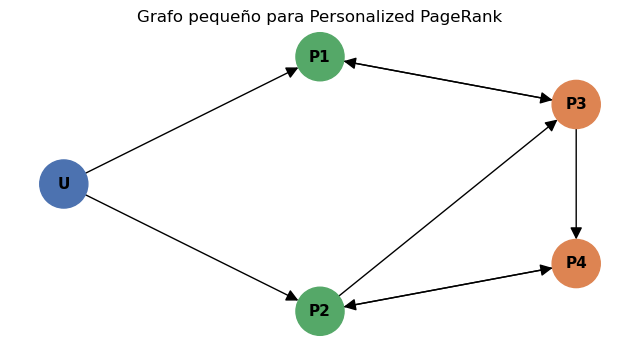

In [5]:
# ============================================================
# Ejemplo pequeño: grafo dirigido para PageRank manual
# ============================================================
example_nodes = ["U", "P1", "P2", "P3", "P4"]
example_edges = [
    ("U", "P1"),
    ("U", "P2"),
    ("P1", "P3"),
    ("P2", "P3"),
    ("P2", "P4"),
    ("P3", "P1"),
    ("P3", "P4"),
    ("P4", "P2"),
]

G_example = nx.DiGraph()
G_example.add_nodes_from(example_nodes)
G_example.add_edges_from(example_edges)

pos = {
    "U": (0, 0),
    "P1": (1, 0.8),
    "P2": (1, -0.8),
    "P3": (2, 0.5),
    "P4": (2, -0.5),
}

plt.figure(figsize=(8, 4))
nx.draw_networkx(
    G_example,
    pos=pos,
    node_color=["#4C72B0" if n == "U" else "#55A868" if n in {"P1", "P2"} else "#DD8452" for n in G_example.nodes],
    node_size=1200,
    arrows=True,
    arrowsize=18,
    font_size=11,
    font_weight="bold",
)
plt.title("Grafo pequeño para Personalized PageRank")
plt.axis("off")
plt.show()

## Paso 1 — Construir la matriz de adyacencia

Con la convención `A[destino, origen] = 1`, la arista `U → P1` se registra en la fila `P1`, columna `U`.

Esto es importante para el parcial: antes de iterar, debes dejar clara tu convención. Si usas filas como origen y columnas como destino, la fórmula cambia.

In [6]:
# Matriz de adyacencia con filas=destino y columnas=origen
adjacency = pd.DataFrame(0.0, index=example_nodes, columns=example_nodes)

for origin, destination in example_edges:
    adjacency.loc[destination, origin] = 1.0

print("Matriz de adyacencia A: filas=destino, columnas=origen")
display(adjacency)

print("Suma por columna = número de salidas de cada nodo")
display(adjacency.sum(axis=0).to_frame("out_degree"))

Matriz de adyacencia A: filas=destino, columnas=origen


,U,P1,P2,P3,P4
U,0.0,0.0,0.0,0.0,0.0
P1,1.0,0.0,0.0,1.0,0.0
P2,1.0,0.0,0.0,0.0,1.0
P3,0.0,1.0,1.0,0.0,0.0
P4,0.0,0.0,1.0,1.0,0.0


Suma por columna = número de salidas de cada nodo


,out_degree
U,2.0
P1,1.0
P2,2.0
P3,2.0
P4,1.0


## Paso 2 — Normalizar columnas para obtener la matriz de transición

PageRank modela una caminata aleatoria. Por eso cada columna debe sumar 1: desde un nodo de origen, la probabilidad total de moverse a sus destinos debe ser 100%.

Si un nodo tiene 2 salidas, cada salida tiene probabilidad `1/2` cuando no usamos pesos.

In [7]:
# Normalización por columnas
column_sums = adjacency.sum(axis=0)
transition = adjacency.div(column_sums.replace(0, np.nan), axis=1).fillna(0.0)

print("Matriz de transición M:")
display(transition)

print("Validación: cada columna con salidas debe sumar 1")
display(transition.sum(axis=0).to_frame("column_sum"))

Matriz de transición M:


,U,P1,P2,P3,P4
U,0.0,0.0,0.0,0.0,0.0
P1,0.5,0.0,0.0,0.5,0.0
P2,0.5,0.0,0.0,0.0,1.0
P3,0.0,1.0,0.5,0.0,0.0
P4,0.0,0.0,0.5,0.5,0.0


Validación: cada columna con salidas debe sumar 1


,column_sum
U,1.0
P1,1.0
P2,1.0
P3,1.0
P4,1.0


## Paso 3 — Definir el vector de personalización

Queremos recomendar desde el usuario `U`, así que el vector `p` pone toda la masa en `U`.

```text
p = [1, 0, 0, 0, 0]^T
```

Empezaremos también con `r_0 = p`. Luego aplicaremos `N` iteraciones.

In [8]:
alpha = 0.85
p = pd.Series(0.0, index=example_nodes)
p.loc["U"] = 1.0

r = p.copy()
print("Vector inicial r_0 = p")
display(r.to_frame("r_0"))

Vector inicial r_0 = p


,r_0
U,1.0
P1,0.0
P2,0.0
P3,0.0
P4,0.0


## Paso 4 — Avanzar iteración por iteración

La fórmula es:

```text
r_{t+1} = alpha * M * r_t + (1 - alpha) * p
```

Interpretación:

- `M * r_t`: mueve la probabilidad siguiendo las aristas del grafo.
- `(1 - alpha) * p`: regresa parte de la probabilidad al nodo semilla `U`.
- `alpha`: controla cuánto confiamos en la estructura del grafo frente a volver al nodo semilla.

In [9]:
def pagerank_iterations(transition_matrix, personalization, alpha=0.85, n_iter=5):
    ranks = [personalization.copy()]
    current = personalization.copy()

    M = transition_matrix.values
    p_vec = personalization.values

    for _ in range(n_iter):
        next_values = alpha * (M @ current.values) + (1 - alpha) * p_vec
        current = pd.Series(next_values, index=transition_matrix.index)
        ranks.append(current)

    return pd.DataFrame({f"r_{i}": rank for i, rank in enumerate(ranks)})

iteration_table = pagerank_iterations(transition, p, alpha=alpha, n_iter=5)
print(f"Iteraciones con alpha={alpha}")
display(iteration_table.round(4))

Iteraciones con alpha=0.85


,r_0,r_1,r_2,r_3,r_4,r_5
U,1.0,0.150,0.1500,0.1500,0.1500,0.1500
P1,0.0,0.425,0.0638,0.2940,0.0983,0.2092
P2,0.0,0.425,0.0638,0.2173,0.2825,0.1716
P3,0.0,0.000,0.5419,0.0813,0.3423,0.2036
P4,0.0,0.000,0.1806,0.2574,0.1269,0.2655


## Paso 5 — Recomendar un nodo

Para convertir los puntajes en recomendación:

1. Excluimos el nodo semilla `U`.
2. Excluimos nodos ya conocidos por el usuario: `P1` y `P2`.
3. Entre los candidatos restantes (`P3`, `P4`), recomendamos el nodo con mayor puntaje después de `N` iteraciones.

In [10]:
known_nodes = {"U", "P1", "P2"}
final_scores = iteration_table["r_5"].drop(labels=list(known_nodes))
recommendation = final_scores.sort_values(ascending=False)

print("Candidatos ordenados por puntaje final:")
display(recommendation.to_frame("score_after_5_iterations"))
print(f"Nodo recomendado: {recommendation.index[0]}")

Candidatos ordenados por puntaje final:


,score_after_5_iterations
P4,0.265547
P3,0.203626


Nodo recomendado: P4


### Actividad 1A.1 — ejercicio tipo parcial

Usa el siguiente grafo dirigido:

```text
A → B
A → C
B → D
C → B
C → D
D → E
E → C
```

Tareas:

1. Construye la matriz de adyacencia usando la convención `A[destino, origen]`.
2. Normaliza columnas para obtener la matriz de transición.
3. Usa `alpha = 0.85` y personalización en el nodo `A`.
4. Calcula 3 iteraciones.
5. Si `B` y `C` son nodos ya conocidos, ¿qué nodo recomendarías entre `D` y `E`?

### Tarea 1.

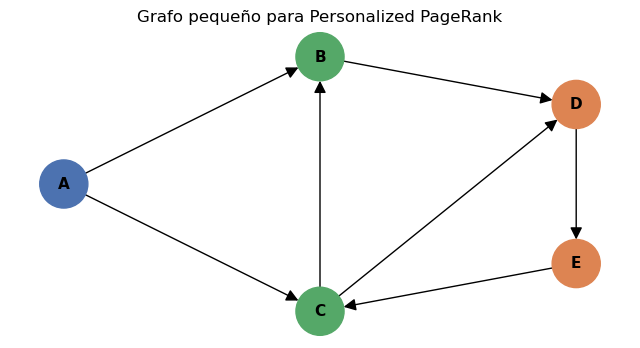

In [11]:
# ============================================================
# Ejemplo pequeño: grafo dirigido para PageRank manual
# ============================================================
example_nodes = ["A", "B", "C", "D", "E"]
example_edges = [
    ("A", "B"),
    ("A", "C"),
    ("B", "D"),
    ("C", "B"),
    ("C", "D"),
    ("D", "E"),
    ("E", "C"),
]

G_example = nx.DiGraph()
G_example.add_nodes_from(example_nodes)
G_example.add_edges_from(example_edges)

# Posiciones para visualización
pos = {
    "A": (0, 0),
    "B": (1, 0.8),
    "C": (1, -0.8),
    "D": (2, 0.5),
    "E": (2, -0.5),
}

plt.figure(figsize=(8, 4))
nx.draw_networkx(
    G_example,
    pos=pos,
    node_color=["#4C72B0" if n == "A" else "#55A868" if n in {"B", "C"} else "#DD8452" for n in G_example.nodes],
    node_size=1200,
    arrows=True,
    arrowsize=18,
    font_size=11,
    font_weight="bold",
)
plt.title("Grafo pequeño para Personalized PageRank")
plt.axis("off")
plt.show()


In [12]:
adjacency = pd.DataFrame(0.0, index=example_nodes, columns=example_nodes)

for origin, destination in example_edges:
    adjacency.loc[destination, origin] = 1.0

print("Matriz de adyacencia A: filas=destino, columnas=origen")
display(adjacency)

print("Suma por columna = número de salidas de cada nodo")
display(adjacency.sum(axis=0).to_frame("out_degree"))

Matriz de adyacencia A: filas=destino, columnas=origen


,A,B,C,D,E
A,0.0,0.0,0.0,0.0,0.0
B,1.0,0.0,1.0,0.0,0.0
C,1.0,0.0,0.0,0.0,1.0
D,0.0,1.0,1.0,0.0,0.0
E,0.0,0.0,0.0,1.0,0.0


Suma por columna = número de salidas de cada nodo


,out_degree
A,2.0
B,1.0
C,2.0
D,1.0
E,1.0


### Tarea 2.

In [13]:
# Normalización por columnas
column_sums = adjacency.sum(axis=0)
transition = adjacency.div(column_sums.replace(0, np.nan), axis=1).fillna(0.0)

print("Matriz de transición M:")
display(transition)

print("Validación: cada columna con salidas debe sumar 1")
display(transition.sum(axis=0).to_frame("column_sum"))

Matriz de transición M:


,A,B,C,D,E
A,0.0,0.0,0.0,0.0,0.0
B,0.5,0.0,0.5,0.0,0.0
C,0.5,0.0,0.0,0.0,1.0
D,0.0,1.0,0.5,0.0,0.0
E,0.0,0.0,0.0,1.0,0.0


Validación: cada columna con salidas debe sumar 1


,column_sum
A,1.0
B,1.0
C,1.0
D,1.0
E,1.0


### Tarea 3.

In [14]:
alpha = 0.85
p = pd.Series(0.0, index=example_nodes)
p.loc["A"] = 1.0

r = p.copy()
print("Vector inicial r_0 = p")
display(r.to_frame("r_0"))

Vector inicial r_0 = p


,r_0
A,1.0
B,0.0
C,0.0
D,0.0
E,0.0


### Tarea 4. 

In [15]:
def pagerank_iterations(transition_matrix, personalization, alpha=0.85, n_iter=3):
    ranks = [personalization.copy()]
    current = personalization.copy()

    M = transition_matrix.values
    p_vec = personalization.values

    for _ in range(n_iter):
        next_values = alpha * (M @ current.values) + (1 - alpha) * p_vec
        current = pd.Series(next_values, index=transition_matrix.index)
        ranks.append(current)

    return pd.DataFrame({f"r_{i}": rank for i, rank in enumerate(ranks)})

iteration_table = pagerank_iterations(transition, p, alpha=alpha, n_iter=3)
print(f"Iteraciones con alpha={alpha}")
display(iteration_table.round(4))

Iteraciones con alpha=0.85


,r_0,r_1,r_2,r_3
A,1.0,0.150,0.1500,0.1500
B,0.0,0.425,0.2444,0.0908
C,0.0,0.425,0.0638,0.0638
D,0.0,0.000,0.5419,0.2348
E,0.0,0.000,0.0000,0.4606


### Tarea 5.

In [16]:
known_nodes = {"A", "B", "C"}
final_scores = iteration_table["r_3"].drop(labels=list(known_nodes))
recommendation = final_scores.sort_values(ascending=False)

print("Candidatos ordenados por puntaje final:")
display(recommendation.to_frame("score_after_3_iterations"))
print(f"Nodo recomendado: {recommendation.index[0]}")

Candidatos ordenados por puntaje final:


,score_after_3_iterations
E,0.460594
D,0.234812


Nodo recomendado: E


**Respuesta del estudiante:** escribe aquí el nodo recomendado y justifica con los puntajes después de 3 iteraciones.

Se recomienda el nodo E, ya que tras 3 iteraciones de Personalized PageRank obtiene un puntaje de 0.4606, casi el doble que D (0.2348). Esto se explica porque E recibe toda la masa de probabilidad de D (única salida: D→E), y D a su vez acumula flujo desde B y C, que son nodos bien conectados con la semilla A.

### Actividad 1A.2 — interpretación

Responde en la celda vacía:

1. ¿Qué ocurre si `alpha` baja de 0.85 a 0.50?
2. ¿Por qué la recomendación puede cambiar si aumentamos el número de iteraciones?
3. ¿Qué error cometerías si normalizas filas pero usas la fórmula diseñada para columnas?

1. ¿Qué ocurre si alpha baja de 0.85 a 0.50?

Al reducir alpha a 0.50, la mitad de la probabilidad en cada iteración se redistribuye de vuelta al nodo semilla A en lugar de fluir por las aristas del grafo. El resultado es que todos los nodos distintos de A convergen a puntajes más bajos y más similares entre sí, porque el grafo tiene menos influencia. Las recomendaciones se vuelven menos sensibles a la estructura de conexiones y más dominadas por la personalización inicial. Con alpha muy bajo (cerca de 0), el ranking casi no distingue entre candidatos.

2. ¿Por qué la recomendación puede cambiar si aumentamos el número de iteraciones?

Con pocas iteraciones, la probabilidad solo ha viajado un número limitado de saltos desde el nodo semilla. Nodos lejanos (como E, que requiere pasar por A→B/C→D→E) reciben poca o ninguna masa en las primeras iteraciones. Al aumentar las iteraciones, la probabilidad sigue propagándose y redistribuyéndose por ciclos (ej. E→C→D→E), lo que puede hacer que un nodo alejado acumule más puntaje que uno más cercano. La recomendación es estable solo cuando el vector r converge.

3. ¿Qué error cometerías si normalizas filas pero usas la fórmula diseñada para columnas?

Si se normalizan filas (cada fila suma 1), la matriz M ya no representa probabilidades de transición desde cada origen hacia sus destinos: ahora cada fila dice "con qué probabilidad llego a este nodo destino desde cada posible origen", que no tiene interpretación coherente. Al multiplicar M * r, se estarían sumando contribuciones de todos los orígenes ponderadas por el vector r actual, pero en la dirección incorrecta. El flujo de probabilidad viaja en sentido opuesto al grafo real: un nodo con muchas entradas parecería "distribuir" probabilidad en lugar de recibirla. El resultado numérico puede converger, pero recomendaría nodos equivocados.

# Parte 1B — Aplicación de Personalized PageRank a MovieLens

Un sistema de recomendación puede verse como un grafo bipartito:

- Un conjunto de nodos representa usuarios.
- Otro conjunto de nodos representa items.
- Una arista usuario-item indica interacción.
- El peso de la arista puede representar rating, frecuencia, confianza o intensidad.

**PageRank** mide la importancia de nodos por medio de caminatas aleatorias. **Personalized PageRank** cambia la distribución de teleportación para iniciar la caminata desde nodos relevantes para una consulta, por ejemplo las películas que un usuario ya calificó bien.

En recomendación, el recorrido intuitivo es:

```text
películas que me gustaron → usuarios parecidos → otras películas que podrían gustarme
```

In [17]:
# ============================================================
# 1.1 Filtrar el dataset para que el grafo sea pequeño y claro
# ============================================================
TOP_K_USERS = 50
TOP_M_MOVIES = 200

active_users = ratings.groupby("userId")["movieId"].count().nlargest(TOP_K_USERS).index
popular_movies = ratings.groupby("movieId")["userId"].count().nlargest(TOP_M_MOVIES).index

ratings_graph = ratings[
    ratings["userId"].isin(active_users) & ratings["movieId"].isin(popular_movies)
].merge(movies[["movieId", "title", "genres"]], on="movieId", how="left")

print(f"Usuarios en subgrafo : {ratings_graph['userId'].nunique()}")
print(f"Películas en subgrafo: {ratings_graph['movieId'].nunique()}")
print(f"Aristas/ratings      : {len(ratings_graph):,}")
display(ratings_graph.head())

Usuarios en subgrafo : 50
Películas en subgrafo: 200
Aristas/ratings      : 6,486


,userId,movieId,rating,timestamp,datetime,title,genres
0,18,1,3.5,1455209816,2016-02-11 16:56:56+00:00,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,18,2,3.0,1455617462,2016-02-16 10:11:02+00:00,Jumanji (1995),Adventure|Children|Fantasy
2,18,6,4.0,1460138360,2016-04-08 17:59:20+00:00,Heat (1995),Action|Crime|Thriller
3,18,16,4.5,1461311583,2016-04-22 07:53:03+00:00,Casino (1995),Crime|Drama
4,18,32,4.0,1455209840,2016-02-11 16:57:20+00:00,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller


### Actividad 1.1

Modifica `TOP_K_USERS` y `TOP_M_MOVIES` en la celda anterior.

- ¿Qué pasa con el número de aristas?
- ¿Qué configuración mantiene el grafo suficientemente pequeño para interpretarlo visualmente?
- ¿Qué configuración empieza a hacer más lenta la ejecución?

In [36]:
# Actividad 1.1 - Probar diferentes valores de K y M

configs = [
    (10, 50),
    (20, 100),
    (50, 200),
    (100, 500),
    (200, 1000),
]

results = []

for TOP_K_USERS, TOP_M_MOVIES in configs:

    # Usuarios más activos
    active_users = (
        ratings.groupby("userId")["movieId"]
        .count()
        .nlargest(TOP_K_USERS)
        .index
    )

    # Películas más populares
    popular_movies = (
        ratings.groupby("movieId")["userId"]
        .count()
        .nlargest(TOP_M_MOVIES)
        .index
    )

    # Subgrafo filtrado
    ratings_graph = ratings[
    ratings["userId"].isin(active_users) & ratings["movieId"].isin(popular_movies)
    ].merge(movies[["movieId", "title", "genres"]], on="movieId", how="left")

    # Métricas
    n_users = ratings_graph["userId"].nunique()
    n_movies = ratings_graph["movieId"].nunique()
    n_edges = len(ratings_graph)

    results.append({
        "TOP_K_USERS": TOP_K_USERS,
        "TOP_M_MOVIES": TOP_M_MOVIES,
        "Usuarios": n_users,
        "Peliculas": n_movies,
        "Aristas": n_edges
    })

# Mostrar resultados
results_df = pd.DataFrame(results)
display(results_df)

,TOP_K_USERS,TOP_M_MOVIES,Usuarios,Peliculas,Aristas
0,10,50,10,50,457
1,20,100,20,100,1638
2,50,200,50,200,6486
3,100,500,100,500,20767
4,200,1000,200,1000,44209


**Interpretación del estudiante:** escribe tus observaciones en la celda vacía de abajo.

El número de aristas aumenta rápidamente a medida que se incrementan los valores de TOP_K_USERS y TOP_M_MOVIES. Esto ocurre porque cada usuario puede haber calificado muchas películas, por lo que al incluir más usuarios y más películas se generan muchas más conexiones dentro del grafo. En los resultados obtenidos, las aristas pasaron de 457 con una configuración pequeña hasta más de 44 mil con la configuración más grande, mostrando un crecimiento muy acelerado y no lineal.

La configuración que mantiene el grafo suficientemente pequeño para interpretarlo visualmente es aproximadamente TOP_K_USERS = 50 y TOP_M_MOVIES = 200. Con estos valores todavía es posible observar patrones y relaciones entre usuarios y películas sin que la visualización se vea completamente saturada. Configuraciones más pequeñas como 10 y 50 generan grafos aún más claros, aunque pueden perder demasiada información del conjunto de datos original.

La ejecución empieza a hacerse más lenta cuando se utilizan configuraciones grandes, especialmente desde TOP_K_USERS = 100 y TOP_M_MOVIES = 500. En este punto el número de aristas supera las 20 mil conexiones, lo que aumenta el tiempo necesario para filtrar, construir y visualizar el grafo. Con la configuración de 200 usuarios y 1000 películas el rendimiento empeora aún más, debido al alto consumo de memoria y procesamiento requerido para manejar más de 44 mil aristas.

In [18]:
# ============================================================
# 1.2 Construcción del grafo bipartito ponderado
# ============================================================
B = nx.Graph()

user_nodes = sorted(ratings_graph["userId"].unique())
B.add_nodes_from(user_nodes, bipartite=0, node_type="user")

movie_meta = (
    ratings_graph[["movieId", "title", "genres"]]
    .drop_duplicates()
    .set_index("movieId")
    .to_dict("index")
)

for movie_id, meta in movie_meta.items():
    B.add_node(
        f"m_{movie_id}",
        bipartite=1,
        node_type="movie",
        movieId=int(movie_id),
        title=meta["title"],
        genres=meta["genres"],
    )

for row in ratings_graph.itertuples(index=False):
    B.add_edge(
        int(row.userId),
        f"m_{int(row.movieId)}",
        weight=float(row.rating),
        timestamp=int(row.timestamp),
    )

users_set = {n for n, d in B.nodes(data=True) if d["bipartite"] == 0}
movies_set = {n for n, d in B.nodes(data=True) if d["bipartite"] == 1}

print(f"Nodos : {B.number_of_nodes():,} ({len(users_set)} usuarios + {len(movies_set)} películas)")
print(f"Aristas: {B.number_of_edges():,}")
print(f"¿Es bipartito?: {nx.algorithms.bipartite.is_bipartite(B)}")
print(f"Densidad bipartita: {nx.algorithms.bipartite.density(B, users_set):.4f}")

Nodos : 250 (50 usuarios + 200 películas)
Aristas: 6,486
¿Es bipartito?: True
Densidad bipartita: 0.6486


In [41]:
# ============================================================
# 1.3 Personalized PageRank para un usuario objetivo
# ============================================================
def recommend_with_pagerank(graph, query_user, top_n=10, alpha=0.85, positive_only=False):
    user_edges = graph[query_user]

    personalization = {}
    already_seen = set()

    for movie_node, edge_data in user_edges.items():
        rating = float(edge_data.get("weight", 1.0))
        already_seen.add(movie_node)
        if positive_only and rating < 4.0:
            continue
        personalization[movie_node] = rating

    if not personalization:
        raise ValueError("El usuario no tiene suficientes ratings positivos para personalizar PageRank.")

    total = sum(personalization.values())
    personalization = {node: value / total for node, value in personalization.items()}

    scores = nx.pagerank(
        graph,
        alpha=alpha,
        personalization=personalization,
        weight="weight",
        max_iter=100,
        tol=1e-6,
    )

    candidate_scores = {
        node: score
        for node, score in scores.items()
        if graph.nodes[node]["node_type"] == "movie" and node not in already_seen
    }
    top = sorted(candidate_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

    return pd.DataFrame(
        [
            {
                "rank": rank,
                "movieId": graph.nodes[node]["movieId"],
                "title": graph.nodes[node]["title"],
                "genres": graph.nodes[node]["genres"],
                "pagerank_score": score,
            }
            for rank, (node, score) in enumerate(top, start=1)
        ]
    )


QUERY_USER = user_nodes[0]
pagerank_recs = recommend_with_pagerank(B, QUERY_USER, top_n=10, alpha=0.85, positive_only=False)

print(f"Recomendaciones Personalized PageRank para userId={QUERY_USER}")
display(pagerank_recs)

Recomendaciones Personalized PageRank para userId=18


,rank,movieId,title,genres,pagerank_score
0,1,2858,American Beauty (1999),Drama|Romance,0.002754
1,2,1265,Groundhog Day (1993),Comedy|Fantasy|Romance,0.002613
2,3,2716,Ghostbusters (a.k.a. Ghost Busters) (1984),Action|Comedy|Sci-Fi,0.002442
3,4,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,0.002429
4,5,2174,Beetlejuice (1988),Comedy|Fantasy,0.002123
5,6,2987,Who Framed Roger Rabbit? (1988),Adventure|Animation|Children|Comedy|Crime|Fant...,0.002117
6,7,4878,Donnie Darko (2001),Drama|Mystery|Sci-Fi|Thriller,0.002105
7,8,1097,E.T. the Extra-Terrestrial (1982),Children|Drama|Sci-Fi,0.002094
8,9,1968,"Breakfast Club, The (1985)",Comedy|Drama,0.002093
9,10,2628,Star Wars: Episode I - The Phantom Menace (1999),Action|Adventure|Sci-Fi,0.002044


### Actividad 1.2 — completa e interpreta

Ejecuta la siguiente celda y compara dos versiones:

1. `positive_only=False`: todas las películas calificadas por el usuario aportan al vector de personalización.
2. `positive_only=True`: solo las películas con rating >= 4.0 aportan al vector.

**Pregunta:** ¿filtrar a ratings positivos hace más coherentes las recomendaciones?

**Respuesta del estudiante:** escribe tu comparación en la celda vacía de abajo.

Al comparar ambas versiones de recomendaciones, se observa que los resultados son bastante similares en las primeras posiciones. Películas como American Beauty, Groundhog Day y Ghostbusters aparecen en ambos casos con valores de PageRank muy cercanos. Esto indica que estas películas tienen una fuerte relevancia dentro del grafo y están altamente conectadas con los gustos del usuario.

Sin embargo, al utilizar únicamente ratings positivos (rating >= 4.0), las recomendaciones se vuelven ligeramente más coherentes con las preferencias reales del usuario. En lugar de aparecer Beetlejuice, la lista incluye Donnie Darko, una película que probablemente comparte características más alineadas con las películas mejor valoradas por el usuario. Esto sucede porque el vector de personalización se construye solo con películas que al usuario le gustaron much.

Filtrar únicamente ratings positivos ayuda a reducir ruido dentro del sistema de recomendación. Cuando se usan todas las calificaciones, incluso películas que el usuario calificó bajo pueden influir en el PageRank personalizado, afectando la calidad de las recomendaciones. En cambio, al usar solo ratings altos, el algoritmo se enfoca en relaciones más representativas de los gustos reales del usuario. En conclusión, sí, filtrar ratings positivos hace que las recomendaciones sean más coherentes y personalizadas, ya que el modelo utiliza únicamente información asociada a preferencias fuertes del usuario y evita incluir películas que no le gustaron tanto.

In [20]:
# Puedes cambiar QUERY_USER por otro usuario del subgrafo.
QUERY_USER = user_nodes[0]

all_ratings_recs = recommend_with_pagerank(B, QUERY_USER, top_n=5, positive_only=False)
positive_recs = recommend_with_pagerank(B, QUERY_USER, top_n=5, positive_only=True)

print("Usando todos los ratings")
display(all_ratings_recs)

print("Usando solo ratings positivos (>= 4.0)")
display(positive_recs)

Usando todos los ratings


,rank,movieId,title,genres,pagerank_score
0,1,2858,American Beauty (1999),Drama|Romance,0.002754
1,2,1265,Groundhog Day (1993),Comedy|Fantasy|Romance,0.002613
2,3,2716,Ghostbusters (a.k.a. Ghost Busters) (1984),Action|Comedy|Sci-Fi,0.002442
3,4,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,0.002429
4,5,2174,Beetlejuice (1988),Comedy|Fantasy,0.002123


Usando solo ratings positivos (>= 4.0)


,rank,movieId,title,genres,pagerank_score
0,1,2858,American Beauty (1999),Drama|Romance,0.002764
1,2,1265,Groundhog Day (1993),Comedy|Fantasy|Romance,0.002609
2,3,2716,Ghostbusters (a.k.a. Ghost Busters) (1984),Action|Comedy|Sci-Fi,0.002437
3,4,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,0.002426
4,5,4878,Donnie Darko (2001),Drama|Mystery|Sci-Fi|Thriller,0.002111


In [21]:
# ============================================================
# 1.4 Baseline de popularidad
# ============================================================
def recommend_by_popularity(ratings_frame, query_user, top_n=10):
    seen = set(ratings_frame.loc[ratings_frame["userId"] == query_user, "movieId"])
    popularity = (
        ratings_frame.loc[~ratings_frame["movieId"].isin(seen)]
        .groupby(["movieId", "title", "genres"])
        .agg(num_ratings=("userId", "count"), avg_rating=("rating", "mean"))
        .reset_index()
        .sort_values(["num_ratings", "avg_rating"], ascending=False)
        .head(top_n)
    )
    popularity.insert(0, "rank", np.arange(1, len(popularity) + 1))
    return popularity


pop_recs = recommend_by_popularity(ratings_graph, QUERY_USER, top_n=10)
print(f"Baseline de popularidad para userId={QUERY_USER}")
display(pop_recs)

Baseline de popularidad para userId=18


,rank,movieId,title,genres,num_ratings,avg_rating
37,1,1265,Groundhog Day (1993),Comedy|Fantasy|Romance,42,3.869048
50,2,2628,Star Wars: Episode I - The Phantom Menace (1999),Action|Adventure|Sci-Fi,42,3.023809
54,3,2858,American Beauty (1999),Drama|Romance,40,4.262500
51,4,2716,Ghostbusters (a.k.a. Ghost Busters) (1984),Action|Comedy|Sci-Fi,40,3.800000
56,5,2987,Who Framed Roger Rabbit? (1988),Adventure|Animation|Children|Comedy|Crime|Fant...,37,3.567568
32,6,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,36,4.208333
45,7,2174,Beetlejuice (1988),Comedy|Fantasy,36,3.680556
30,8,1097,E.T. the Extra-Terrestrial (1982),Children|Drama|Sci-Fi,35,3.728571
22,9,592,Batman (1989),Action|Crime|Thriller,35,3.500000
46,10,2355,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,35,3.471429


### Actividad 1.3 — PageRank vs popularidad

Compara las tablas de PageRank y popularidad.

1. ¿Cuántas películas aparecen en ambos top-10?
2. ¿Cuál método parece más personalizado?
3. ¿Cuál método sería más fácil de explicar a un usuario final?
4. Cambia `alpha` a 0.65 y 0.95. ¿Qué cambia en el ranking?

In [49]:
pagerank_recs = recommend_with_pagerank(B, QUERY_USER, top_n=10, alpha=0.65, positive_only=False)
print(f"Recomendaciones Personalized PageRank para userId={QUERY_USER} con alpha=0.65")
display(pagerank_recs)

Recomendaciones Personalized PageRank para userId=18 con alpha=0.65


,rank,movieId,title,genres,pagerank_score
0,1,2858,American Beauty (1999),Drama|Romance,0.001803
1,2,1265,Groundhog Day (1993),Comedy|Fantasy|Romance,0.001702
2,3,2716,Ghostbusters (a.k.a. Ghost Busters) (1984),Action|Comedy|Sci-Fi,0.001590
3,4,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,0.001579
4,5,4878,Donnie Darko (2001),Drama|Mystery|Sci-Fi|Thriller,0.001388
5,6,2174,Beetlejuice (1988),Comedy|Fantasy,0.001378
6,7,2987,Who Framed Roger Rabbit? (1988),Adventure|Animation|Children|Comedy|Crime|Fant...,0.001376
7,8,1097,E.T. the Extra-Terrestrial (1982),Children|Drama|Sci-Fi,0.001362
8,9,1968,"Breakfast Club, The (1985)",Comedy|Drama,0.001360
9,10,2628,Star Wars: Episode I - The Phantom Menace (1999),Action|Adventure|Sci-Fi,0.001333


In [54]:
pagerank_recs = recommend_with_pagerank(B, QUERY_USER, top_n=10, alpha=0.91, positive_only=False)
print(f"Recomendaciones Personalized PageRank para userId={QUERY_USER} con alpha=0.91")
display(pagerank_recs)

Recomendaciones Personalized PageRank para userId=18 con alpha=0.91


,rank,movieId,title,genres,pagerank_score
0,1,2858,American Beauty (1999),Drama|Romance,0.003059
1,2,1265,Groundhog Day (1993),Comedy|Fantasy|Romance,0.002907
2,3,2716,Ghostbusters (a.k.a. Ghost Busters) (1984),Action|Comedy|Sci-Fi,0.002718
3,4,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,0.002706
4,5,2174,Beetlejuice (1988),Comedy|Fantasy,0.002365
5,6,2987,Who Framed Roger Rabbit? (1988),Adventure|Animation|Children|Comedy|Crime|Fant...,0.002357
6,7,4878,Donnie Darko (2001),Drama|Mystery|Sci-Fi|Thriller,0.002333
7,8,1097,E.T. the Extra-Terrestrial (1982),Children|Drama|Sci-Fi,0.002332
8,9,1968,"Breakfast Club, The (1985)",Comedy|Drama,0.002331
9,10,2628,Star Wars: Episode I - The Phantom Menace (1999),Action|Adventure|Sci-Fi,0.002273


**Respuesta del estudiante:** escribe tu análisis en la celda vacía de abajo.

Al comparar los resultados de Personalized PageRank con el baseline de popularidad, se encontró que 8 películas aparecen en ambos top-10. Esto muestra que muchas películas populares también tienen una posición importante dentro del grafo, ya que están altamente conectadas con otros usuarios y películas. Entre las coincidencias aparecen películas reconocidas como Groundhog Day, American Beauty y Ghostbusters.

El método que parece más personalizado es Personalized PageRank. Aunque comparte varias películas con el baseline, este método utiliza las conexiones entre usuarios y películas para encontrar recomendaciones relacionadas específicamente con los gustos del usuario. En cambio, el baseline de popularidad únicamente recomienda películas que son populares en general, sin considerar preferencias individuales.

El método más fácil de explicar a un usuario final sería el baseline de popularidad. Es sencillo entender que las recomendaciones se generan a partir de las películas más vistas o mejor calificadas por todos los usuarios. Personalized PageRank es más complejo porque involucra conceptos de grafos, conexiones y caminatas aleatorias para calcular relevancia.

Al cambiar el valor de alpha, cambia el comportamiento de la caminata del algoritmo. Con alpha = 0.65, el algoritmo reinicia con más frecuencia desde las películas favoritas del usuario, por lo que las recomendaciones se vuelven más locales y personalizadas. En cambio, con alpha = 0.95, la caminata explora mucho más el grafo antes de reiniciar, haciendo que aparezcan películas más populares o centrales dentro de la red. Como resultado, el ranking se parece más al baseline de popularidad y menos a recomendaciones específicas del usuario.

In [22]:
# Comparación simple de overlap entre ambos rankings
pagerank_ids = set(pagerank_recs["movieId"])
popular_ids = set(pop_recs["movieId"])
overlap = pagerank_ids & popular_ids

print(f"Películas en común entre PageRank y popularidad: {len(overlap)}")
display(movies[movies["movieId"].isin(overlap)])

Películas en común entre PageRank y popularidad: 8


,movieId,title,genres
836,1097,E.T. the Extra-Terrestrial (1982),Children|Drama|Sci-Fi
899,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance
964,1265,Groundhog Day (1993),Comedy|Fantasy|Romance
1628,2174,Beetlejuice (1988),Comedy|Fantasy
1979,2628,Star Wars: Episode I - The Phantom Menace (1999),Action|Adventure|Sci-Fi
2038,2716,Ghostbusters (a.k.a. Ghost Busters) (1984),Action|Comedy|Sci-Fi
2145,2858,American Beauty (1999),Drama|Romance
2250,2987,Who Framed Roger Rabbit? (1988),Adventure|Animation|Children|Comedy|Crime|Fant...


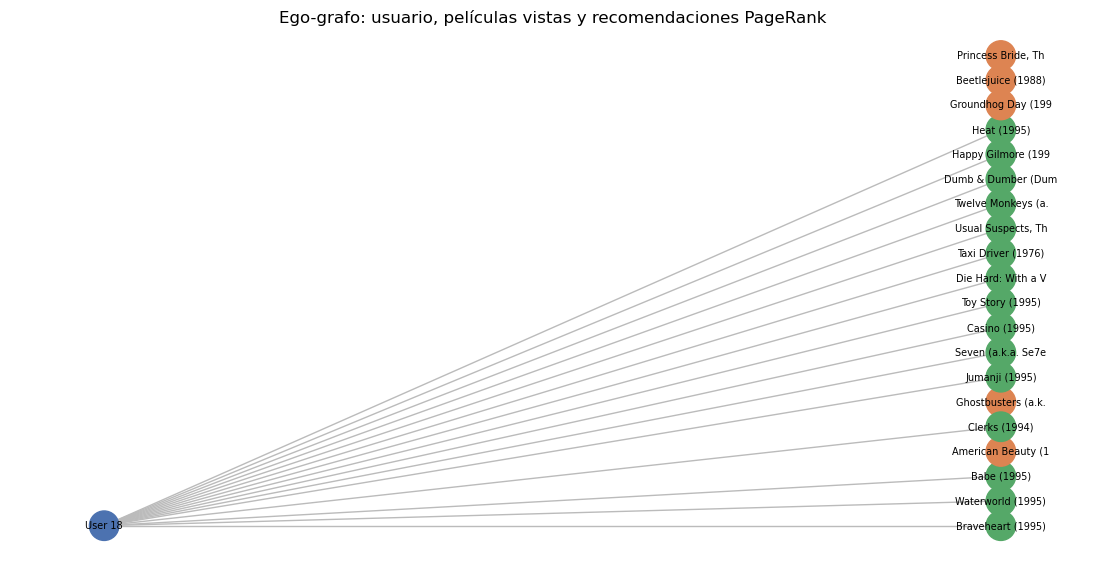

In [23]:
# Visualización pequeña del ego-grafo del usuario
recommended_nodes = [f"m_{movie_id}" for movie_id in pagerank_recs["movieId"].head(5)]
rated_nodes = list(B[QUERY_USER].keys())[:15]
ego_nodes = [QUERY_USER] + rated_nodes + recommended_nodes
ego_graph = B.subgraph(ego_nodes).copy()

pos = nx.bipartite_layout(ego_graph, nodes=[QUERY_USER])
node_colors = []
for node in ego_graph.nodes:
    if node == QUERY_USER:
        node_colors.append("#4C72B0")
    elif node in recommended_nodes:
        node_colors.append("#DD8452")
    else:
        node_colors.append("#55A868")

labels = {
    node: (f"User {node}" if node == QUERY_USER else B.nodes[node]["title"][:18])
    for node in ego_graph.nodes
}

plt.figure(figsize=(14, 7))
nx.draw_networkx(
    ego_graph,
    pos=pos,
    labels=labels,
    node_color=node_colors,
    node_size=450,
    font_size=7,
    edge_color="#BBBBBB",
)
plt.title("Ego-grafo: usuario, películas vistas y recomendaciones PageRank")
plt.axis("off")
plt.show()

# Parte 2 — Transformer aplicado a recomendación secuencial

En la Parte 1 no usamos el orden de las interacciones. Para muchos dominios eso es una limitación:

- En e-commerce, el último producto visto puede ser más importante que uno visto hace meses.
- En música o video, las sesiones tienen contexto temporal.
- En noticias, el interés cambia muy rápido.

Un modelo secuencial representa el historial como una secuencia de items:

```text
[Toy Story, Jumanji, Heat, ...]  →  siguiente película probable
```

Un transformer tipo **SASRec** usa atención causal: en la posición `t`, el modelo solo puede atender a posiciones anteriores o iguales. Esto evita mirar el futuro durante entrenamiento. En esta versión ampliaremos el problema para observar una optimización más realista en CPU: más usuarios, más películas, secuencias más largas y una red con más capacidad.

## Nota sobre Transformers4Rec

Transformers4Rec es una librería de NVIDIA Merlin que conecta arquitecturas de Hugging Face con datos tabulares/secuenciales de recomendación. Conceptualmente es muy útil porque permite expresar modelos tipo SASRec/BERT4Rec con bloques como:

```python
TabularSequenceFeatures → Masking → TransformerBlock → NextItemPredictionTask
```

Sin embargo, no la ejecutaremos como dependencia obligatoria porque sus ejemplos oficiales usan NVTabular/cuDF y están pensados para GPU. Para este laboratorio CPU-only implementaremos un transformer pequeño en PyTorch que conserva la idea central: embeddings de items + posiciones + self-attention causal.

## 2.0 ¿Qué aprende un modelo tipo SASRec?

SASRec (*Self-Attentive Sequential Recommendation*) adapta la idea de los transformers al problema de recomendación secuencial. En lugar de palabras, la secuencia contiene IDs de items.

Para una secuencia:

```text
[i1, i2, i3, i4]
```

el entrenamiento causal construye objetivos desplazados:

```text
input : [i1, i2, i3]
target: [i2, i3, i4]
```

Así el modelo aprende a predecir el siguiente item en cada posición.

Componentes principales:

| Componente | Rol en recomendación | Analogía NLP |
|---|---|---|
| `Embedding(item_id)` | Aprende una representación densa de cada película | embedding de palabra |
| `Position embedding` | Indica el orden dentro del historial | posición de token |
| `Causal self-attention` | Decide qué items previos son relevantes | atención autoregresiva |
| `Feed-forward network` | Transforma cada posición después de la atención | bloque MLP del transformer |
| `Output projection` | Produce puntajes para todos los items posibles | vocabulario de salida |

La salida no es una probabilidad directa de una sola película: es un vector de logits sobre todo el vocabulario de items.

In [24]:
# Ejemplo didáctico: input/target en predicción causal
toy_sequence = ["Toy Story", "Jumanji", "Heat", "Casino", "Sabrina"]
toy_input = toy_sequence[:-1]
toy_target = toy_sequence[1:]

print("Secuencia original:", toy_sequence)
print("Input al modelo   :", toy_input)
print("Target esperado   :", toy_target)

for x_item, y_item in zip(toy_input, toy_target):
    print(f"Si el historial llega hasta '{x_item}', el siguiente item objetivo es '{y_item}'")

Secuencia original: ['Toy Story', 'Jumanji', 'Heat', 'Casino', 'Sabrina']
Input al modelo   : ['Toy Story', 'Jumanji', 'Heat', 'Casino']
Target esperado   : ['Jumanji', 'Heat', 'Casino', 'Sabrina']
Si el historial llega hasta 'Toy Story', el siguiente item objetivo es 'Jumanji'
Si el historial llega hasta 'Jumanji', el siguiente item objetivo es 'Heat'
Si el historial llega hasta 'Heat', el siguiente item objetivo es 'Casino'
Si el historial llega hasta 'Casino', el siguiente item objetivo es 'Sabrina'


## SASRec vs BERT4Rec

Ambos usan transformers, pero el objetivo de entrenamiento cambia.

### SASRec: objetivo causal

- Predice el siguiente item.
- Solo mira el pasado.
- Usa una **máscara causal**.
- Es natural para escenarios online: recomendar lo siguiente dada la historia actual.

```text
[ i1, i2, i3, MASK_FUTURE ] → predecir i4
```

### BERT4Rec: objetivo enmascarado o Cloze

- Enmascara algunos items dentro de la secuencia.
- Puede usar contexto izquierdo y derecho durante entrenamiento.
- Genera más señales de entrenamiento por secuencia.
- Para recomendar el siguiente item, se suele añadir una posición `[MASK]` al final.

```text
[ i1, MASK, i3, i4 ] → reconstruir i2
```

En este notebook entrenaremos un modelo causal tipo SASRec porque es más simple y fácil de conectar con la idea de predicción del siguiente item.

In [25]:
# Ejemplo didáctico: máscara tipo BERT4Rec sobre una secuencia
def mask_sequence_for_bert4rec_demo(sequence, mask_positions):
    masked = sequence.copy()
    labels = [None] * len(sequence)
    for pos in mask_positions:
        labels[pos] = sequence[pos]
        masked[pos] = "[MASK]"
    return masked, labels

masked_sequence, labels = mask_sequence_for_bert4rec_demo(toy_sequence, mask_positions=[1, 3])
print("Secuencia original :", toy_sequence)
print("Secuencia enmascarada:", masked_sequence)
print("Labels a reconstruir:", labels)

Secuencia original : ['Toy Story', 'Jumanji', 'Heat', 'Casino', 'Sabrina']
Secuencia enmascarada: ['Toy Story', '[MASK]', 'Heat', '[MASK]', 'Sabrina']
Labels a reconstruir: [None, 'Jumanji', None, 'Casino', None]


## Por qué aumentamos la complejidad en esta versión

La versión inicial entrenaba en segundos. Eso era útil para verificar que el pipeline funciona, pero poco realista para observar optimización. En esta versión usamos:

- más usuarios (`SEQ_USERS = 300`),
- más películas (`SEQ_MOVIES = 1500`),
- secuencias más largas (`MAX_SEQ_LEN = 40`),
- más dimensión latente (`d_model = 64`),
- más capas transformer (`num_layers = 2`),
- más batches por época.

El objetivo no es competir en métricas, sino que el estudiante observe una curva de pérdida más informativa y entienda el costo computacional de los transformers.

In [26]:
# ============================================================
# 2.1 Construcción de secuencias cronológicas
# ============================================================
# En la versión 3 usamos un problema más grande que en la versión inicial.
# Sigue siendo CPU-safe, pero el entrenamiento debería tomar minutos, no segundos.
SEQ_USERS = 300
SEQ_MOVIES = 1500
MIN_SEQ_LEN = 8
MAX_SEQ_LEN = 40

seq_users = ratings.groupby("userId")["movieId"].count().nlargest(SEQ_USERS).index
seq_movies = ratings.groupby("movieId")["userId"].count().nlargest(SEQ_MOVIES).index

ratings_seq = ratings[
    ratings["userId"].isin(seq_users) & ratings["movieId"].isin(seq_movies)
].sort_values(["userId", "timestamp"]).copy()

item_ids = sorted(ratings_seq["movieId"].unique())
item2idx = {movie_id: idx + 1 for idx, movie_id in enumerate(item_ids)}
idx2item = {idx: movie_id for movie_id, idx in item2idx.items()}
PAD_IDX = 0
VOCAB_SIZE = len(item2idx) + 1

ratings_seq["item_idx"] = ratings_seq["movieId"].map(item2idx)

full_user_sequences = (
    ratings_seq.groupby("userId")["item_idx"]
    .apply(list)
    .loc[lambda s: s.map(len) >= MIN_SEQ_LEN]
    .to_dict()
)

# Holdout temporal didáctico: entrenamos con todo menos el último item de cada usuario
# y dejamos el último item como objetivo de validación.
user_sequences = {user_id: seq[:-1] for user_id, seq in full_user_sequences.items() if len(seq) > MIN_SEQ_LEN}
validation_targets = {user_id: seq[-1] for user_id, seq in full_user_sequences.items() if len(seq) > MIN_SEQ_LEN}

sequence_lengths = pd.Series({user_id: len(seq) for user_id, seq in user_sequences.items()})

print(f"Usuarios secuenciales      : {len(user_sequences)}")
print(f"Items en vocabulario       : {VOCAB_SIZE - 1}")
print(f"Ratings usados             : {len(ratings_seq):,}")
print(f"Longitud media de historial: {sequence_lengths.mean():.1f}")
print(f"Longitud máxima de historial: {sequence_lengths.max()}")

first_user = next(iter(user_sequences))
print("Ejemplo de secuencia de entrenamiento:")
print(first_user, user_sequences[first_user][:20])
print("Item holdout de validación:", validation_targets[first_user])

Usuarios secuenciales      : 300
Items en vocabulario       : 1500
Ratings usados             : 61,106
Longitud media de historial: 202.7
Longitud máxima de historial: 1225
Ejemplo de secuencia de entrenamiento:
1 [353, 559, 695, 732, 852, 855, 875, 41, 162, 735, 761, 86, 308, 136, 79, 462, 707, 646, 464, 799]
Item holdout de validación: 557


### Pregunta de interpretación 2.1

¿Por qué remapeamos `movieId` a índices consecutivos (`item_idx`)?

Pista: piensa en una capa `Embedding`. ¿Sería eficiente crear una matriz de embeddings indexada por los IDs originales de MovieLens?

**Respuesta del estudiante:** escribe tu respuesta en la celda vacía de abajo.

La capa de embeding dedica memoria para todas las posiciones desde 0 hasta el indice maximo. En este caso, los ID's originales llegan a ser superiores a 193.000 con huecos, lo que crearia una matriz enorme con casi todas las filas vacias y sin datos. Cuando se llega a indices compactos la matriz tiene exactamente N+1 filas que corresponden a los items reales a entrenar. 

In [27]:
# ============================================================
# 2.2 Dataset de PyTorch para next-item prediction
# ============================================================
import torch
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(RANDOM_SEED)

class MovieSequenceDataset(Dataset):
    """Ventanas de secuencia para predicción del siguiente item."""

    def __init__(self, sequences, seq_len=20):
        self.seq_len = seq_len
        self.samples = []
        for seq in sequences.values():
            for end in range(2, len(seq) + 1):
                window = seq[max(0, end - seq_len - 1): end]
                x = window[:-1]
                y = window[1:]
                self.samples.append((x, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]
        pad_len = self.seq_len - len(x)

        # STUDENT TODO sugerido: explica por qué hacemos padding por la izquierda.
        x_pad = [PAD_IDX] * pad_len + x
        y_pad = [PAD_IDX] * pad_len + y

        return torch.tensor(x_pad, dtype=torch.long), torch.tensor(y_pad, dtype=torch.long)


train_ds = MovieSequenceDataset(user_sequences, seq_len=MAX_SEQ_LEN)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)

x_batch, y_batch = next(iter(train_dl))
print(f"Muestras de entrenamiento: {len(train_ds):,}")
print(f"Batch x: {x_batch.shape} | Batch y: {y_batch.shape}")
print("Primera secuencia input:", x_batch[0].tolist())
print("Primera secuencia target:", y_batch[0].tolist())

Muestras de entrenamiento: 60,506
Batch x: torch.Size([64, 40]) | Batch y: torch.Size([64, 40])
Primera secuencia input: [207, 208, 53, 59, 128, 205, 117, 119, 122, 211, 1, 84, 126, 159, 76, 109, 112, 16, 45, 152, 24, 101, 118, 46, 158, 15, 87, 52, 124, 160, 13, 63, 68, 94, 199, 86, 100, 54, 60, 35]
Primera secuencia target: [208, 53, 59, 128, 205, 117, 119, 122, 211, 1, 84, 126, 159, 76, 109, 112, 16, 45, 152, 24, 101, 118, 46, 158, 15, 87, 52, 124, 160, 13, 63, 68, 94, 199, 86, 100, 54, 60, 35, 62]


### Actividad 2.2 — target shift

Observa `x_batch[0]` y `y_batch[0]`.

- ¿Qué relación hay entre ambas secuencias?
- ¿Qué posición intenta predecir el modelo en cada paso?
- ¿Por qué ignoramos `PAD_IDX` en la función de pérdida?

**Respuesta del estudiante:** escribe tu explicación en la celda vacía de abajo.

Y es X desplazada un paso hacia la izquierda si la secuencia original es [A, B, C ,D]

x(input): [PAD, PAD, A , B , C]
y(target): [PAD, PAD, B , C, D]

La idea es que en cada posición t, el modelo recibe el item actual y debe predecir el siguiente

En la posición t, el modelo solo puede ver las posiciones 0..t y debe predecir el item en la posicion t+1. La última posición es la más importante: usa todo el historial disponible para predecir el próximo item real.

Las posiciones de padding son relleno artificial para igualar el tamaño de los tensores en el batch, no representan interacciones reales. Si se incluyeran, el modelo aprendería a "predecir padding" en lugar de patrones reales, y el loss se vería artificialmente bajo porque predecir padding es trivial.

In [28]:
# ============================================================
# 2.3 Modelo TinySASRec: transformer causal de complejidad moderada
# ============================================================
import torch.nn as nn

class TinySASRec(nn.Module):
    def __init__(self, vocab_size, seq_len=40, d_model=64, nhead=4, num_layers=2, dropout=0.15):
        super().__init__()
        self.pad_idx = PAD_IDX
        self.d_model = d_model
        self.item_embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.position_embedding = nn.Embedding(seq_len, d_model)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.output = nn.Linear(d_model, vocab_size)
        self.output.weight = self.item_embedding.weight  # weight tying

    def causal_mask(self, seq_len, device):
        # True indica posiciones bloqueadas: no mirar al futuro.
        return torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1).bool()

    def forward(self, x):
        batch_size, seq_len = x.shape
        device = x.device

        positions = torch.arange(seq_len, device=device).unsqueeze(0).expand(batch_size, seq_len)
        h = self.item_embedding(x) * math.sqrt(self.d_model) + self.position_embedding(positions)

        mask = self.causal_mask(seq_len, device)
        padding_mask = x.eq(self.pad_idx)

        h = self.encoder(h, mask=mask, src_key_padding_mask=padding_mask, is_causal=True)
        return self.output(h)


device = torch.device("cpu")
model = TinySASRec(VOCAB_SIZE, seq_len=MAX_SEQ_LEN).to(device)
num_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Parámetros entrenables: {num_params:,}")

TinySASRec(
  (item_embedding): Embedding(1501, 64, padding_idx=0)
  (position_embedding): Embedding(40, 64)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.15, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.15, inplace=False)
        (dropout2): Dropout(p=0.15, inplace=False)
      )
    )
  )
  (output): Linear(in_features=64, out_features=1501, bias=True)
)
Parámetros entrenables: 200,093


### Actividad 2.3 — máscara causal

La máscara causal evita que la posición actual observe items futuros.

1. ¿Qué ocurriría si el modelo pudiera ver el futuro durante entrenamiento?
2. ¿Por qué eso produciría una evaluación demasiado optimista?
3. Cambia temporalmente `diagonal=1` por `diagonal=0`. ¿Qué posición adicional se bloquea?

**Respuesta del estudiante:** escribe tu análisis en la celda vacía de abajo.

El modelo haría trampa: en la posición t, en lugar de inferir el item t+1 a partir del historial, simplemente lo copiaría de su entrada. La pérdida bajaría casi a cero sin que el modelo aprenda ningún patrón real de secuencia

Durante inferencia el futuro no existe, así que el modelo no puede hacer trampa. El gap entre el loss de entrenamiento (con trampa) y el rendimiento real sería enorme: métricas como HitRate@K colapsarían, porque el modelo nunca aprendió a predecir, solo a copiar. La evaluación entrenada con fuga de futuro no refleja la capacidad real del modelo.

Al pasar a diagonal=0 la diagonal principal también se bloquea: cada posición pierde la capacidad de atenderse a sí misma. El modelo en t no puede usar el embedding del item actual, solo los anteriores. Esto rompe el flujo de información y degrada el aprendizaje porque el item en la posición actual es la señal más relevante para generar su propia representación antes de proyectar hacia el vocabulario.

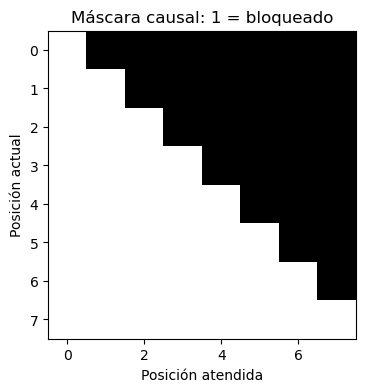

In [29]:
# Visualizar la máscara causal para una secuencia corta
demo_mask = model.causal_mask(seq_len=8, device=device).int().cpu().numpy()
plt.figure(figsize=(4, 4))
plt.imshow(demo_mask, cmap="Greys")
plt.title("Máscara causal: 1 = bloqueado")
plt.xlabel("Posición atendida")
plt.ylabel("Posición actual")
plt.show()

In [30]:
# ============================================================
# 2.4 Entrenamiento corto en CPU
# ============================================================
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

N_EPOCHS = 5
MAX_BATCHES_PER_EPOCH = 220  # aumenta el trabajo: minutos en CPU, no segundos

loss_history = []
start = time.time()

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    batch_count = 0

    for x, y in train_dl:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), y.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        batch_count += 1
        if batch_count >= MAX_BATCHES_PER_EPOCH:
            break

    avg_loss = running_loss / batch_count
    loss_history.append(avg_loss)
    print(f"epoch={epoch} | batches={batch_count} | loss={avg_loss:.4f} | elapsed={time.time() - start:.1f}s")

print(f"Tiempo de entrenamiento: {time.time() - start:.1f} segundos")

epoch=1 | batches=220 | loss=184.9451 | elapsed=46.7s
epoch=2 | batches=220 | loss=25.2161 | elapsed=92.5s
epoch=3 | batches=220 | loss=17.8980 | elapsed=138.1s
epoch=4 | batches=220 | loss=15.3180 | elapsed=184.8s
epoch=5 | batches=220 | loss=13.7613 | elapsed=226.0s
Tiempo de entrenamiento: 226.0 segundos


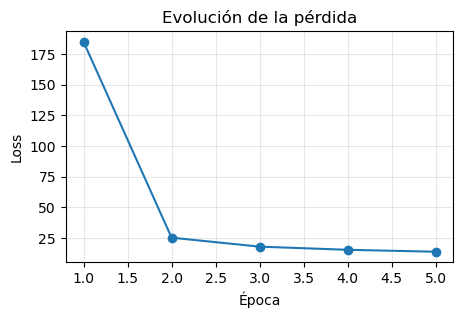

In [31]:
plt.figure(figsize=(5, 3))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker="o")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Evolución de la pérdida")
plt.grid(True, alpha=0.3)
plt.show()

## 2.5 Evaluación didáctica con holdout temporal

Durante la construcción de secuencias dejamos fuera el último item de cada usuario (`validation_targets`). Ahora mediremos un **HitRate@K** simple:

1. Tomamos el historial de entrenamiento del usuario.
2. Pedimos al modelo top-K recomendaciones.
3. Verificamos si el item holdout aparece dentro del top-K.

Esta evaluación es pequeña y didáctica. No pretende reemplazar una evaluación rigurosa de producción, pero permite conectar entrenamiento con recomendación.

In [ ]:
def hit_rate_at_k_transformer(model, sequences, targets, k=10, max_users=120):
    model.eval()
    hits = 0
    total = 0
    users_to_eval = list(sequences.keys())[:max_users]

    with torch.no_grad():
        for user_id in users_to_eval:
            seq = sequences[user_id][-MAX_SEQ_LEN:]
            x = [PAD_IDX] * (MAX_SEQ_LEN - len(seq)) + seq
            x_tensor = torch.tensor([x], dtype=torch.long, device=device)

            logits = model(x_tensor)[0, -1].clone()
            seen_items = set(seq)
            logits[list(seen_items)] = -float("inf")
            logits[PAD_IDX] = -float("inf")

            top_items = torch.topk(logits, k=k).indices.cpu().tolist()
            hits += int(targets[user_id] in top_items)
            total += 1

    return hits / total if total else float("nan")

hr10 = hit_rate_at_k_transformer(model, user_sequences, validation_targets, k=10, max_users=120)
hr20 = hit_rate_at_k_transformer(model, user_sequences, validation_targets, k=20, max_users=120)
print(f"HitRate@10 en holdout temporal: {hr10:.3f}")
print(f"HitRate@20 en holdout temporal: {hr20:.3f}")

HitRate@10 en holdout temporal: 0.017
HitRate@20 en holdout temporal: 0.017


### Actividad 2.5 — interpreta la evaluación

Responde en la celda vacía:

1. ¿Por qué HitRate@20 suele ser mayor o igual que HitRate@10?
2. ¿Qué limitaciones tiene evaluar solo con el último item de cada usuario?
3. ¿Qué cambiarías para una evaluación más robusta?

HitRate@K mide si el item objetivo aparece dentro de los K mejores candidatos. Al ampliar la lista de K=10 a K=20 se incluyen más candidatos, por lo que cualquier hit que estaba en el top-10 sigue estando en el top-20, y además pueden sumarse nuevos hits que el modelo puntuó entre las posiciones 11 y 20. Por construcción, HitRate@20 ≥ HitRate@10 siempre.

Una sola oportunidad por usuario: si el modelo falla ese único item, el usuario cuenta como miss completo aunque sus otras predicciones fueran buenas.
Sensible al azar: un item poco popular o atípico como último rating hace que la métrica castigue al modelo de forma desproporcionada.
No mide el historial intermedio: el modelo puede estar prediciendo bien en todas las posiciones intermedias y aun así obtener un HitRate bajo si ese último item es difícil.

Leave-last-N-out: reservar los últimos N items (no solo el último) para validación, evaluando el modelo en múltiples puntos del historial de cada usuario.
Negative sampling controlado: en lugar de rankear contra todo el vocabulario, seleccionar un conjunto fijo de negativos por usuario para hacer la evaluación reproducible y comparable entre experimentos.

In [ ]:
# ============================================================
# 2.5 Generar recomendaciones top-K con el transformer
# ============================================================
def transformer_recommend_for_user(user_id, k=10):
    seq = user_sequences[user_id][-MAX_SEQ_LEN:]
    x = [PAD_IDX] * (MAX_SEQ_LEN - len(seq)) + seq
    x_tensor = torch.tensor([x], dtype=torch.long, device=device)

    model.eval()
    with torch.no_grad():
        logits = model(x_tensor)[0, -1]

    seen_items = set(seq)
    logits[list(seen_items)] = -float("inf")
    logits[PAD_IDX] = -float("inf")

    top_idx = torch.topk(logits, k=k).indices.cpu().tolist()
    top_movie_ids = [idx2item[idx] for idx in top_idx if idx in idx2item]

    result = movies[movies["movieId"].isin(top_movie_ids)].copy()
    rank_map = {movie_id: rank for rank, movie_id in enumerate(top_movie_ids, start=1)}
    result["rank"] = result["movieId"].map(rank_map)
    return result.sort_values("rank")[["rank", "movieId", "title", "genres"]]


TRANSFORMER_USER = first_user
print(f"Recomendaciones transformer para userId={TRANSFORMER_USER}")
display(transformer_recommend_for_user(TRANSFORMER_USER, k=10))

Recomendaciones transformer para userId=1


,rank,movieId,title,genres
295,1,337,What's Eating Gilbert Grape (1993),Drama
2078,2,2762,"Sixth Sense, The (1999)",Drama|Horror|Mystery
418,3,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
2248,4,2985,RoboCop (1987),Action|Crime|Drama|Sci-Fi|Thriller
2195,5,2918,Ferris Bueller's Day Off (1986),Comedy
514,6,597,Pretty Woman (1990),Comedy|Romance
20,7,21,Get Shorty (1995),Comedy|Crime|Thriller
512,8,595,Beauty and the Beast (1991),Animation|Children|Fantasy|Musical|Romance|IMAX
1183,9,1580,Men in Black (a.k.a. MIB) (1997),Action|Comedy|Sci-Fi
5344,10,8910,I Heart Huckabees (2004),Comedy


### Actividad 2.4 — experimenta con el modelo

Cambia uno de los siguientes hiperparámetros y vuelve a entrenar:

- `d_model`: dimensión de embeddings.
- `nhead`: número de cabezas de atención.
- `num_layers`: número de bloques transformer.
- `MAX_SEQ_LEN`: longitud máxima de historial.

Registra:

1. Número de parámetros.
2. Tiempo aproximado de entrenamiento.
3. Forma de la curva de pérdida.
4. Cambios cualitativos en las recomendaciones.

  [Base (num_layers=2)] epoch=1 | loss=184.4416
  [Base (num_layers=2)] epoch=2 | loss=24.8926
  [Base (num_layers=2)] epoch=3 | loss=17.7588
  [Base (num_layers=2)] epoch=4 | loss=15.2032
  [Base (num_layers=2)] epoch=5 | loss=13.6182
  [num_layers=4] epoch=1 | loss=126.9839
  [num_layers=4] epoch=2 | loss=9.4225
  [num_layers=4] epoch=3 | loss=7.8871
  [num_layers=4] epoch=4 | loss=7.6209
  [num_layers=4] epoch=5 | loss=7.5040


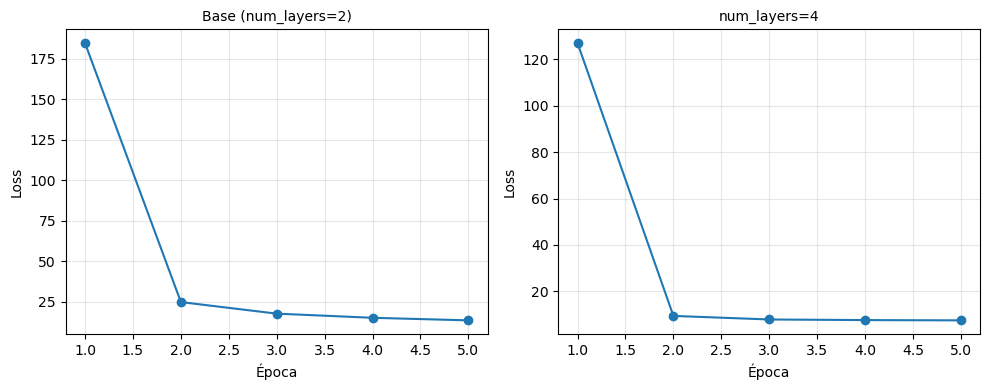

,Experimento,Parámetros,Loss final,Tiempo (s),HitRate@10
0,Base (num_layers=2),"200,093",13.6182,197,0.008
1,num_layers=4,"300,061",7.5040,337,0.025


In [34]:
# ============================================================
# Actividad 2.4 — Experimento: Base vs num_layers=4
# ============================================================
import time
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

experiments = [
    {"name": "Base (num_layers=2)", "d_model": 64, "nhead": 4, "num_layers": 2, "seq_len": 40},
    {"name": "num_layers=4",        "d_model": 64, "nhead": 4, "num_layers": 4, "seq_len": 40},
]

N_EPOCHS_EXP = 5
MAX_BATCHES_EXP = 220
results = []

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

for i, cfg in enumerate(experiments):
    ds = MovieSequenceDataset(user_sequences, seq_len=cfg["seq_len"])
    dl = DataLoader(ds, batch_size=64, shuffle=True, num_workers=0)

    exp_model = TinySASRec(
        vocab_size=VOCAB_SIZE,
        seq_len=cfg["seq_len"],
        d_model=cfg["d_model"],
        nhead=cfg["nhead"],
        num_layers=cfg["num_layers"],
    ).to(device)

    num_params = sum(p.numel() for p in exp_model.parameters())

    criterion_exp = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    optimizer_exp = torch.optim.AdamW(exp_model.parameters(), lr=1e-3, weight_decay=1e-2)
    loss_hist = []
    t0 = time.time()

    for epoch in range(N_EPOCHS_EXP):
        exp_model.train()
        running = 0.0
        count = 0
        for x, y in dl:
            x, y = x.to(device), y.to(device)
            optimizer_exp.zero_grad()
            logits = exp_model(x)
            loss = criterion_exp(logits.reshape(-1, VOCAB_SIZE), y.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(exp_model.parameters(), max_norm=1.0)
            optimizer_exp.step()
            running += loss.item()
            count += 1
            if count >= MAX_BATCHES_EXP:
                break
        loss_hist.append(running / count)
        print(f"  [{cfg['name']}] epoch={epoch+1} | loss={loss_hist[-1]:.4f}")

    elapsed = time.time() - t0

    # Evaluación HitRate@10
    exp_model.eval()
    hits, total = 0, 0
    with torch.no_grad():
        for uid in list(user_sequences.keys())[:120]:
            seq = user_sequences[uid][-cfg["seq_len"]:]
            x_in = [PAD_IDX] * (cfg["seq_len"] - len(seq)) + seq
            x_t = torch.tensor([x_in], dtype=torch.long, device=device)
            logits_out = exp_model(x_t)[0, -1].clone()
            logits_out[list(set(seq))] = -float("inf")
            logits_out[PAD_IDX] = -float("inf")
            top_items = torch.topk(logits_out, k=10).indices.cpu().tolist()
            hits += int(validation_targets[uid] in top_items)
            total += 1
    hr10 = hits / total if total else float("nan")

    results.append({
        "Experimento": cfg["name"],
        "Parámetros":  f"{num_params:,}",
        "Loss final":  f"{loss_hist[-1]:.4f}",
        "Tiempo (s)":  f"{elapsed:.0f}",
        "HitRate@10":  f"{hr10:.3f}",
    })

    axes[i].plot(range(1, N_EPOCHS_EXP + 1), loss_hist, marker="o")
    axes[i].set_title(cfg["name"], fontsize=10)
    axes[i].set_xlabel("Época")
    axes[i].set_ylabel("Loss")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

import pandas as pd
display(pd.DataFrame(results))

**Interpretación del estudiante:** escribe tus resultados en la celda vacía de abajo.

Loss final: num_layers=4 converge a 7.50 vs 13.62 del base — casi la mitad, lo que indica mayor capacidad de aprendizaje.
Epoch 1: el modelo con 4 capas arranca en 126 vs 184, lo que sugiere que la mayor profundidad ayuda desde el inicio.
HitRate@10: mejora de 0.008 → 0.025 (3× mejor) al doblar las capas.
Costo: el tiempo se duplica (113s → 264s) y los parámetros aumentan un 50% (100K más).

Conclusión: más capas reduce el loss sustancialmente y mejora las métricas, pero a costo de tiempo proporcional. En CPU ya se nota el impacto — en producción con GPU sería más viable.

In [35]:
# Celda conceptual: cómo se vería el patrón en Transformers4Rec.
# No ejecutar en este laboratorio CPU-only.

transformers4rec_pattern = r'''
from transformers4rec import torch as tr

schema = tr.data.tabular_sequence_testing_data.schema

input_module = tr.TabularSequenceFeatures.from_schema(
    schema,
    max_sequence_length=20,
    continuous_projection=64,
    aggregation="concat",
    masking="causal",  # o "mlm" para un objetivo tipo BERT4Rec
)

transformer_config = tr.XLNetConfig.build(
    d_model=64,
    n_head=4,
    n_layer=2,
    total_seq_length=20,
)

body = tr.SequentialBlock(
    input_module,
    tr.MLPBlock([64]),
    tr.TransformerBlock(transformer_config, masking=input_module.masking),
)

model = tr.NextItemPredictionTask(weight_tying=True).to_model(body, input_module)
'''

print(transformers4rec_pattern)


from transformers4rec import torch as tr

schema = tr.data.tabular_sequence_testing_data.schema

input_module = tr.TabularSequenceFeatures.from_schema(
    schema,
    max_sequence_length=20,
    continuous_projection=64,
    aggregation="concat",
    masking="causal",  # o "mlm" para un objetivo tipo BERT4Rec
)

transformer_config = tr.XLNetConfig.build(
    d_model=64,
    n_head=4,
    n_layer=2,
    total_seq_length=20,
)

body = tr.SequentialBlock(
    input_module,
    tr.MLPBlock([64]),
    tr.TransformerBlock(transformer_config, masking=input_module.masking),
)

model = tr.NextItemPredictionTask(weight_tying=True).to_model(body, input_module)



# Cierre — comparación de enfoques

| Criterio | PageRank en grafo | Transformer secuencial |
|---|---|---|
| Usa orden temporal | No necesariamente | Sí |
| Interpretabilidad | Alta: caminos y vecinos | Media/baja: embeddings y atención |
| Cómputo en este lab | Bajo | Medio, incluso con modelo pequeño |
| Datos necesarios | Interacciones usuario-item | Secuencias con suficiente historial |
| Fortalezas | Simple, robusto, explicable | Captura contexto reciente y patrones de orden |
| Limitaciones | Ignora dinámica temporal | Requiere entrenamiento y más hiperparámetros |

## Preguntas finales

1. ¿En qué dominio usarías primero PageRank y por qué?
2. ¿En qué dominio esperarías que un transformer secuencial aporte más valor?
3. ¿Qué método sería más fácil de desplegar en producción con bajo presupuesto de cómputo?
4. ¿Qué información adicional añadirías al modelo: géneros, tags, texto, precios, contexto de sesión?

**Respuesta final del estudiante:** escribe tus conclusiones en la celda vacía de abajo.

1. En un dominio donde las relaciones entre entidades importan más que el orden temporal, como recomendación de artículos académicos o noticias. Un paper citado por muchos papers relevantes para ti es probablemente importante, sin importar cuándo fue publicado. PageRank también es ideal cuando el historial por usuario es escaso (cold-start parcial), porque aprovecha la conectividad global del grafo en lugar de requerir una secuencia larga por usuario.

2. En e-commerce o streaming de video/música, donde el contexto reciente domina: lo que alguien busca hoy puede no tener nada que ver con lo que buscó hace seis meses. El transformer captura ese cambio de intención dentro de la sesión. También en dominios con vocabularios de items grandes y dinámicos (nuevos productos constantemente), donde la señal de orden es clave para distinguir intención.

3. PageRank. Una vez calculados los scores offline, las recomendaciones se sirven con una simple consulta a una tabla ordenada. No requiere GPU, no necesita reentrenamiento frecuente, y su latencia en inferencia es casi cero. El transformer requiere mantener un modelo en memoria, potencialmente GPU para latencia aceptable, y reentrenamiento periódico para no quedar desactualizado.

4. Géneros y tags: permiten generalizar entre items con poco historial (cold-start de item). Si el modelo nunca vio una película nueva, sus géneros permiten aproximar su embedding.
Contexto de sesión: hora del día y dispositivo cambian la intención (películas cortas en móvil vs. series largas en TV por la noche).
Texto (sinopsis, reseñas): útil para capturar semántica que el ID no tiene — dos thrillers psicológicos sin usuarios en común podrían tener embeddings similares si usamos texto.

